In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
%matplotlib inline


In [327]:
data = pd.read_csv(r'C:\Akshaya\synthetic_dna_dataset.csv')
data.head()
kmer_size = 6
human_data = data[data['Class_Label'] == 'Human'].copy()

In [328]:
def getkmers(sequence, size = kmer_size ):
    return [sequence[i:i+size].lower() for i in range(len(sequence) - size + 1)]

In [329]:
human_data['words'] = human_data.apply(lambda x: getkmers(x['Sequence']),axis = 1)
human_data = human_data.drop('Sequence', axis = 1)

In [330]:
human_data.head()

,Sample_ID,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,words
3,SAMPLE_4,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium,"[actacg, ctacgc, tacgcg, acgcgg, cgcgga, gcgga..."
4,SAMPLE_5,46.0,54.0,100,24,30,25,21,0.818,0,Human,High,"[ttcaat, tcaatg, caatgc, aatgca, atgcag, tgcag..."
8,SAMPLE_9,42.0,58.0,100,32,26,19,23,0.935,1,Human,Low,"[gattaa, attaat, ttaatg, taatga, aatgac, atgac..."
14,SAMPLE_15,50.0,50.0,100,25,25,24,26,0.766,0,Human,Medium,"[ggagcc, gagcct, agcctt, gcctta, ccttac, cttac..."
22,SAMPLE_23,58.0,42.0,100,21,21,33,25,0.942,1,Human,Medium,"[aggcac, ggcacg, gcacgt, cacgtt, acgttg, cgttg..."


In [331]:
human_text= list(human_data['words'])
for item in range (len(human_text)):
    human_text[item] = ' '.join(human_text[item])
y_data = human_data['Disease_Risk'].values

In [332]:
print(human_text[2])

gattaa attaat ttaatg taatga aatgac atgacg tgacgc gacgcc acgcca cgccaa gccaat ccaatt caattc aattct attctc ttctcg tctcgg ctcggg tcgggt cgggtc gggtcc ggtccc gtccca tcccat cccata ccataa cataat ataatt taattc aattct attctc ttctcg tctcgt ctcgta tcgtaa cgtaaa gtaaat taaata aaataa aataaa ataaaa taaaat aaaatg aaatga aatgaa atgaac tgaaca gaacac aacacg acacgt cacgtt acgtta cgttat gttatc ttatcg tatcga atcgac tcgacg cgacgt gacgta acgtat cgtatg gtatga tatgag atgaga tgagag gagagt agagtc gagtca agtcaa gtcaac tcaacg caacga aacgaa acgaat cgaatg gaatgt aatgtg atgtgg tgtgga gtggag tggagg ggagga gaggaa aggaac ggaacg gaacgc aacgct acgctt cgctta gcttag cttagt ttagtg tagtgt agtgtc


In [333]:
y_data

array(['Medium', 'High', 'Low', 'Medium', 'Medium', 'High', 'Low', 'High',
       'High', 'Low', 'Medium', 'Low', 'Medium', 'High', 'Medium', 'Low',
       'High', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'High', 'High',
       'Low', 'High', 'Medium', 'Medium', 'Low', 'Medium', 'High', 'Low',
       'Medium', 'Low', 'Low', 'Low', 'Low', 'High', 'Medium', 'High',
       'Medium', 'Low', 'Low', 'High', 'Low', 'Low', 'Low', 'High',
       'High', 'High', 'Medium', 'Medium', 'Low', 'Medium', 'Medium',
       'Low', 'High', 'High', 'Low', 'Medium', 'Medium', 'Low', 'Medium',
       'Medium', 'Medium', 'Low', 'Low', 'Medium', 'High', 'Low', 'High',
       'High', 'Low', 'High', 'High', 'High', 'High', 'Low', 'Low',
       'High', 'Medium', 'High', 'Medium', 'Low', 'High', 'Medium',
       'Medium', 'High', 'High', 'High', 'Medium', 'Medium', 'High',
       'High', 'Low', 'Medium', 'Low', 'High', 'Low', 'High', 'Low',
       'High', 'Medium', 'Low', 'High', 'High', 'Medium', 'Medium', 'Low'

In [334]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(4,4))
X = cv.fit_transform(human_text)
# from sklearn.feature_extraction.text import TfidfVectorizer
# cv = TfidfVectorizer(ngram_range=(4,4))
# X = cv.fit_transform(dog_texts)

In [335]:
print(X.shape)

(749, 60787)


<Axes: xlabel='Disease_Risk'>

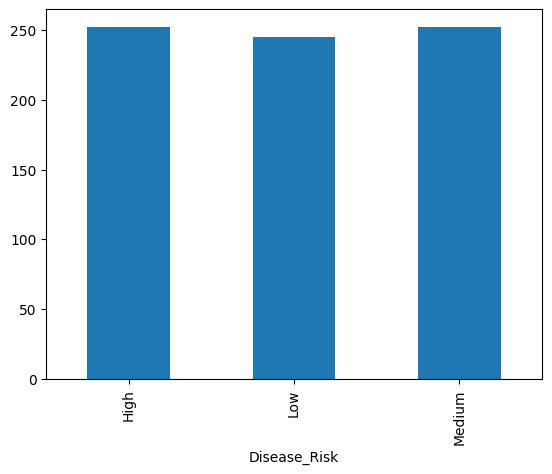

In [311]:
human_data['Disease_Risk'].value_counts().sort_index().plot.bar()

In [342]:
X_train, X_test, y_train, y_test = train_test_split(X, y_data, test_size=0.2, random_state=42)

In [343]:
print(X_train.shape)
print(X_test.shape)

(599, 60787)
(150, 60787)


In [344]:
 from sklearn.naive_bayes import MultinomialNB
 classifier = MultinomialNB(alpha=0.1)


 classifier.fit(X_train, y_train)


,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [345]:
y_pred = classifier.predict(X_test)

In [346]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print("Confusion Matrix\n")
print(pd.crosstab(pd.Series(y_test, name='Acutal'), pd.Series(y_pred, name='Predicted')))
def get_metrics(y_test, y_predicted):
    accuracy = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, average='weighted')
    recall = recall_score(y_test, y_predicted, average='weighted')
    f1= f1_score(y_test, y_predicted, average='weighted')
    return accuracy, precision, recall, f1
accuracy,precision, recall, f1 = get_metrics(y_test, y_pred)
print("accuracy = %.3f \nprecision = %.3f \nrecall = %.3f \nf1 =%.3f" % (accuracy, precision, recall, f1))

Confusion Matrix

Predicted  High  Low  Medium
Acutal                      
High         44   11      10
Low          26   12       6
Medium       27    9       5
accuracy = 0.407 
precision = 0.372 
recall = 0.407 
f1 =0.372


In [347]:
print(len(set(y_data)))  # number of unique classes
print(len(y_data)) 

3
749
